# Análisis del Precio de la desigualdad en Colombia

[Alejandro Morales](mailto:ja.moralesv@hotmail.com)

## Motivación

Este es un ejercicio inspirado en la lectura del libro "El Precio de la desigualdad" de Joseph Stiglitz aplicado para Colombia usando métodos de estádistica Bayesiana e Inferencia Causal.

In [14]:
%%capture
!pip install wbgapi
!pip install matplotlib
!pip install seaborn
!pip install wid

In [3]:
import pandas as pd
import wbgapi as wb
import matplotlib.pyplot as plt

# 1. Definir los países (ISO Codes) y los indicadores de interés
# NY.GDP.PCAP.PP.CD: PIB per cápita PPP
# SI.POV.GINI: Índice de Gini
countries = ['COL', 'USA']
indicators = {
    'NY.GDP.PCAP.PP.CD': 'GDP_per_capita',
    'SI.POV.GINI': 'Gini_Index'
}



In [4]:
# 2. Extraer datos del Banco Mundial (últimos 20 años)
df = wb.data.DataFrame(indicators.keys(), countries, mrv=20).T
df.index = df.index.str.replace('YR', '').astype(int)

In [5]:
df.describe()

economy               COL                           USA            
series  NY.GDP.PCAP.PP.CD SI.POV.GINI NY.GDP.PCAP.PP.CD SI.POV.GINI
count           20.000000   18.000000         20.000000   20.000000
mean         13973.983106   53.522222      58886.454605   41.210000
std           4030.589574    1.273511      12349.053520    0.622305
min           8432.333291   50.900000      44123.399647   39.700000
25%          10722.683224   52.700000      48624.488263   41.050000
50%          13343.708961   53.750000      56001.431905   41.300000
75%          15684.805352   54.400000      64608.119724   41.700000
max          22349.436440   55.100000      85809.900385   41.900000

In [7]:
df.head()

economy               COL                           USA            
series  NY.GDP.PCAP.PP.CD SI.POV.GINI NY.GDP.PCAP.PP.CD SI.POV.GINI
2005          8432.333291        53.9      44123.399647        41.3
2006          9154.089262         NaN      46301.987649        41.7
2007          9909.290314         NaN      48050.227412        41.1
2008         10307.064988        55.0      48570.059427        41.1
2009         10367.348956        54.1      47194.950089        40.9

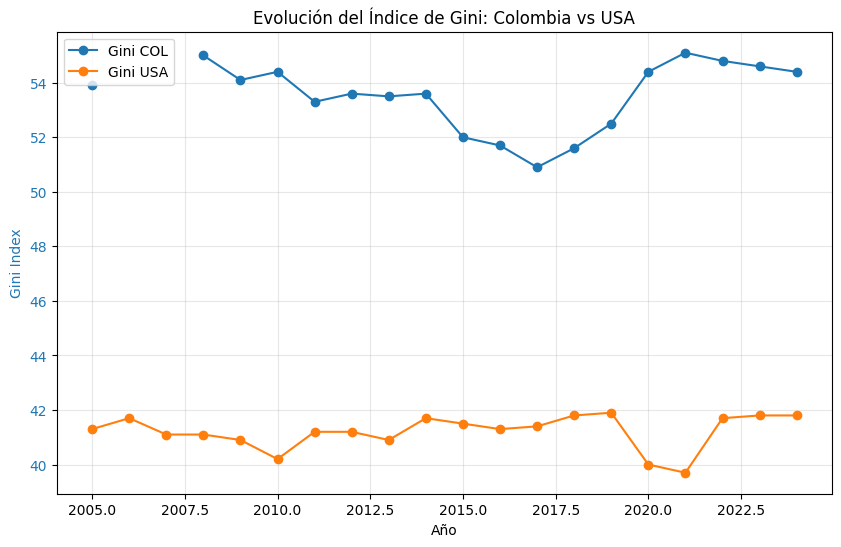

In [10]:


# 3. Visualización crítica: Brecha de Desigualdad vs Riqueza
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Gini Index', color=color)
for c in countries:
    ax1.plot(df.index, df[c]['SI.POV.GINI'], label=f'Gini {c}', marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

plt.title('Evolución del Índice de Gini: Colombia vs USA')
plt.grid(True, alpha=0.3)
plt.show()

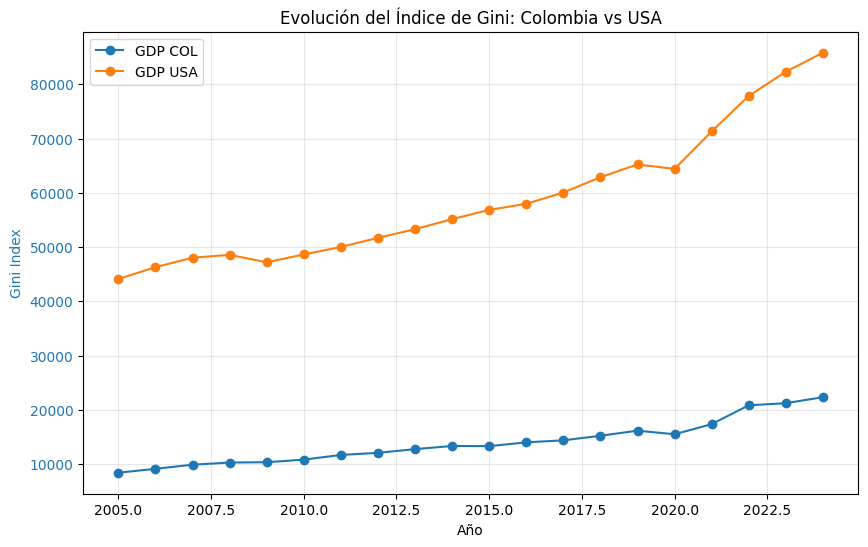

In [11]:
# 3. Visualización crítica: Brecha de Desigualdad vs Riqueza
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Gini Index', color=color)
for c in countries:
    ax1.plot(df.index, df[c]['NY.GDP.PCAP.PP.CD'], label=f'GDP {c}', marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

plt.title('Evolución del Índice de Gini: Colombia vs USA')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
wb.search('salary')

ID,Name,Field,Value
SG.LAW.EQRM.WK,,Longdefinition,"...of equal value. “Remuneration” refers to the ordinary, basic or minimum wage or salary and any additional emoluments payable directly or indirectly, whether in cash..."
SG.MMR.LEVE.EP,,Longdefinition,...to reinstate the returning employee in an equivalent or better position and salary than the employee had pre-leave. Where the maternity leave regime explicitly...


<Response [404]>

### Descargar un archivo usando `requests`

El siguiente código demuestra cómo descargar un archivo de una URL específica y guardarlo en el sistema de archivos local. Usamos la biblioteca `requests` para manejar la solicitud HTTP.

In [19]:
import requests
from tqdm.auto import tqdm

# Define la URL del archivo que quieres descargar
# Reemplaza esta URL con la URL del archivo que deseas descargar
file_url = 'https://wid.world/bulk_download/wid_all_data.zip'

# Define el nombre con el que se guardará el archivo localmente
# Asegúrate de que el nombre del archivo incluya la extensión correcta (por ejemplo, .pdf, .jpg, .txt)
local_filename = 'wid_all_data.zip'

# Define el tamaño de cada "chunk" (pedazo) de datos a descargar.
# Puedes aumentar este valor (ej. 16384, 32768, 65536) si tienes una conexión estable y quieres probar a acelerar.
chunk_size = 8192 # bytes

try:
    # Envía una solicitud GET para descargar el contenido del archivo
    response = requests.get(file_url, stream=True)
    response.raise_for_status()  # Lanza una excepción para códigos de estado de error (4xx o 5xx)

    total_size_in_bytes = int(response.headers.get('content-length', 0))
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)

    # Abre un archivo en modo binario de escritura y guarda el contenido
    with open(local_filename, 'wb') as file:
        for chunk in response.iter_content(chunk_size=chunk_size): # Itera sobre el contenido en "chunks"
            progress_bar.update(len(chunk))
            file.write(chunk)
    progress_bar.close()

    print(f'Archivo descargado exitosamente como {local_filename}')
except requests.exceptions.RequestException as e:
    print(f'Error al descargar el archivo: {e}')

  0%|          | 0.00/853M [00:00<?, ?iB/s]

Archivo descargado exitosamente como wid_all_data.zip


In [21]:
!unzip wid_all_data.zip

Archive:  wid_all_data.zip
  inflating: WID_countries.csv       
  inflating: WID_data_AD.csv         
  inflating: WID_data_AE.csv         
  inflating: WID_data_AF.csv         
  inflating: WID_data_AG.csv         
  inflating: WID_data_AI.csv         
  inflating: WID_data_AL.csv         
  inflating: WID_data_AM.csv         
  inflating: WID_data_AN.csv         
  inflating: WID_data_AO.csv         
  inflating: WID_data_AR.csv         
  inflating: WID_data_AS.csv         
  inflating: WID_data_AT.csv         
  inflating: WID_data_AU.csv         
  inflating: WID_data_AW.csv         
  inflating: WID_data_AZ.csv         
  inflating: WID_data_Al.csv         
  inflating: WID_data_BA.csv         
  inflating: WID_data_BB.csv         
  inflating: WID_data_BD.csv         
  inflating: WID_data_BE.csv         
  inflating: WID_data_BF.csv         
  inflating: WID_data_BG.csv         
  inflating: WID_data_BH.csv         
  inflating: WID_data_BI.csv         
  inflating: WID_data_B

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns

In [44]:
wid_col_df = pd.read_csv(filepath_or_buffer='WID_data_CO.csv', sep=';')
wid_usa_df = pd.read_csv(filepath_or_buffer='WID_data_US.csv', sep=';')

In [43]:
wid_col_df.head()

,country,variable,percentile,year,value,age,pop
0,CO,ehfcari999,p0p100,1990,32.122842,999,i
1,CO,ehfcari999,p0p100,1991,30.876706,999,i
2,CO,ehfcari999,p0p100,1992,33.739995,999,i
3,CO,ehfcari999,p0p100,1993,33.856059,999,i
4,CO,ehfcari999,p0p100,1994,35.186588,999,i


In [45]:
wid_usa_df.head()

,country,variable,percentile,year,value,age,pop
0,US,ehfcari999,p0p100,1990,2284.334507,999,i
1,US,ehfcari999,p0p100,1991,2275.642153,999,i
2,US,ehfcari999,p0p100,1992,2370.115893,999,i
3,US,ehfcari999,p0p100,1993,2363.898468,999,i
4,US,ehfcari999,p0p100,1994,2384.815002,999,i


In [ ]:
# https://wid.world/codes-dictionary/

In [49]:

def filter_by_vars(df, filter_variables):
    # Definir los prefijos de las variables que queremos filtrar


    # Crear una máscara booleana para filtrar el DataFrame por los prefijos de las variables
    # Inicializamos la máscara con todos los valores en False
    mask = pd.Series([False] * len(df), index=df.index)

    # Iteramos sobre cada prefijo y actualizamos la máscara
    for prefix in filter_variables:
        mask = mask | df['variable'].str.startswith(prefix, na=False)

    # Aplicar la máscara para filtrar el DataFrame
    wid_df_filtered = df[mask].copy()

    return wid_df_filtered


In [58]:
filter_variables = [
    'sptinc', # Participación del ingreso nacional (Top 1% vs 50% inf)
    'fcapit', # Rentas de capital (Factorial)
    'flabor', # Rentas del trabajo (Factorial)
    'mnweal'  # Riqueza nacional neta
]


In [59]:
wid_col_df_filtered = filter_by_vars(wid_col_df, filter_variables)

In [63]:
vars_col = set(wid_col_df_filtered.variable.unique())
vars_col

{'mnweali999', 'sptincj992', 'sptincj999'}

In [56]:
wid_usa_df_filtered = filter_by_vars(wid_usa_df, filter_variables)

In [64]:
vars_usa = set(wid_usa_df_filtered.variable.unique())
vars_usa

{'mnweali999',
 'sptincf992',
 'sptinci992',
 'sptinci996',
 'sptinci999',
 'sptincj992',
 'sptincj999',
 'sptincm992',
 'sptinct992'}

In [67]:
common_vars = list(vars_col & vars_usa)
common_vars

['mnweali999', 'sptincj999', 'sptincj992']

In [91]:
df_total = pd.concat([
    filter_by_vars(wid_usa_df, common_vars),
    filter_by_vars(wid_col_df, common_vars)
])

In [92]:
df_total

,country,variable,percentile,year,value,age,pop
196316,US,sptincj999,p0p0,1820,0.000000e+00,999,j
196317,US,sptincj999,p0p0,1850,0.000000e+00,999,j
196318,US,sptincj999,p0p0,1880,0.000000e+00,999,j
196319,US,sptincj999,p0p0,1900,0.000000e+00,999,j
196320,US,sptincj999,p0p0,1910,0.000000e+00,999,j
...,...,...,...,...,...,...,...
502997,CO,mnweali999,p0p100,2020,4.401698e+15,999,i
502998,CO,mnweali999,p0p100,2021,4.399382e+15,999,i
502999,CO,mnweali999,p0p100,2022,4.837492e+15,999,i
503000,CO,mnweali999,p0p100,2023,5.081691e+15,999,i


In [126]:
# 1. Creamos un dataframe solo con la riqueza nacional (que es constante por año/país)
df_wealth = df_total[df_total['variable'] == 'mnweali999'][['country', 'year', 'value']]
df_wealth.columns = ['country', 'year', 'national_wealth']

# 2. Creamos un dataframe con la distribución del ingreso (filtrando por percentiles clave)
df_income = df_total[(df_total['variable'] == 'sptincj992') & (df_total['percentile'].isin(['p99p100', 'p0p50']))]

# 3. Merge para tener riqueza e ingreso en la misma fila
df_final = pd.merge(df_income, df_wealth, on=['country', 'year'])



In [129]:
df_final

,country,variable,percentile,year,value,age,pop,national_wealth
0,US,sptincj992,p0p50,1820,0.1651,992,j,1.289903e+11
1,US,sptincj992,p0p50,1850,0.1300,992,j,5.566131e+11
2,US,sptincj992,p0p50,1880,0.1700,992,j,1.576934e+12
3,US,sptincj992,p0p50,1900,0.1629,992,j,3.912990e+12
4,US,sptincj992,p0p50,1910,0.1709,992,j,5.537628e+12
...,...,...,...,...,...,...,...,...
341,CO,sptincj992,p99p100,2020,0.2066,992,j,4.401698e+15
342,CO,sptincj992,p99p100,2021,0.2091,992,j,4.399382e+15
343,CO,sptincj992,p99p100,2022,0.2696,992,j,4.837492e+15
344,CO,sptincj992,p99p100,2023,0.2245,992,j,5.081691e+15


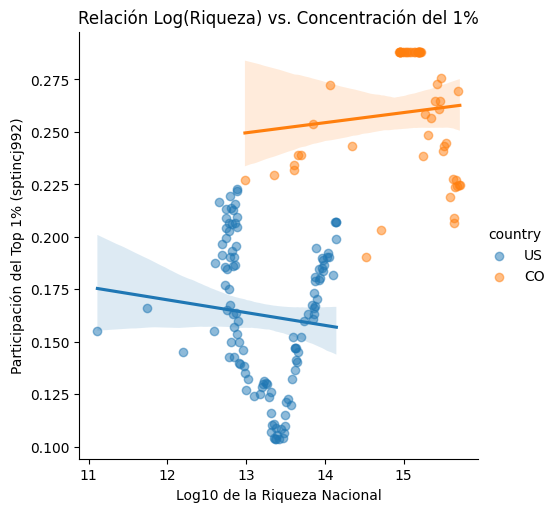

In [133]:
# Creamos una columna con el logaritmo de la riqueza
df_final['log_national_wealth'] = np.log10(df_final['national_wealth'])

# Graficamos de nuevo
sns.lmplot(
    data=df_final[df_final['percentile']=='p99p100'],
    x='log_national_wealth',
    y='value',
    hue='country',
    scatter_kws={'alpha':0.5}
)

plt.title('Relación Log(Riqueza) vs. Concentración del 1%')
plt.xlabel('Log10 de la Riqueza Nacional')
plt.ylabel('Participación del Top 1% (sptincj992)')
plt.show()

In [ ]:
# https://gemini.google.com/app/6c87bccd009817d5